TensorFlow version: 2.19.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.4650 - loss: 0.7633 - val_accuracy: 0.4000 - val_loss: 0.7251
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4900 - loss: 0.6969 - val_accuracy: 0.6000 - val_loss: 0.6871
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5000 - loss: 0.6909 - val_accuracy: 0.4200 - val_loss: 0.6939
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5950 - loss: 0.6851 - val_accuracy: 0.6000 - val_loss: 0.6806
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5300 - loss: 0.6797 - val_accuracy: 0.5000 - val_loss: 0.6936


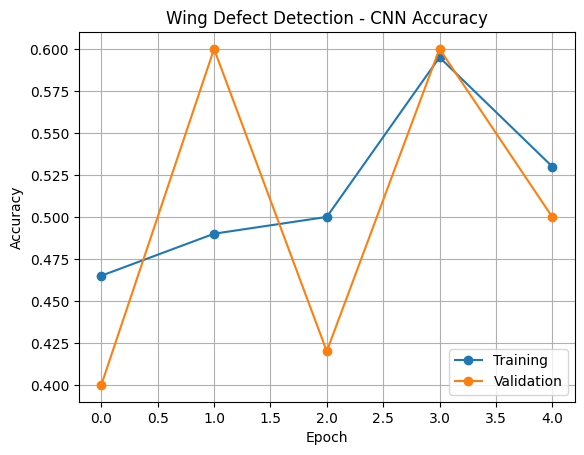

Final accuracy: 0.5000


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

X_train = np.random.rand(200, 32, 32, 3)
y_train = np.random.randint(0, 2, 200)
X_test = np.random.rand(50, 32, 32, 3)
y_test = np.random.randint(0, 2, 50)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], 'o-', label='Training')
plt.plot(history.history['val_accuracy'], 'o-', label='Validation')
plt.title('Wing Defect Detection - CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
plt.show()

print(f"Final accuracy: {history.history['val_accuracy'][-1]:.4f}")